# CSCI 580 - Artificial Intelligence: Final Project - MNIST Handwritten Digit Image Detection via MLP

`Group #6`: Joseph Lorenzo Bautista, Jesus Javier Ramirez, Kevin Xiong, and Adam Lepage

** Project Requirements **
- Train an MLP on MNIST.
- Validate while training.
- Testing on:
    1. MNIST test set.
    2. Each group's images.
- Record and gather accuracy stats for both.
- See and evaluate what works and what doesn't, and iterate to improve.


## 1. Imports and Setup

In [ ]:
# Mounting the Google Drive for the groups digits datasets
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Verifying and making sure that the images are getting retrieved from Google Drive
import os
print(os.listdir('/content/drive/MyDrive/digits')[:10])

['1-8-1.png', '1-3-2.png', '0-4-2.png', '1-8-4.png', '0-8-3.png', '0-6-2.png', '1-9-3.png', '2-1-1.png', '1-5-3.png', '0-9-2.png']


In [ ]:
# Importing the necessary packages

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import OrderedDict

import matplotlib.pyplot as plt

# Using CUDA (A100 GPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using Device:', device)
    print('GPU Name:    ', torch.cuda.get_device_name(0))
    print('CUDA Version:', torch.version.cuda)

    # Speedups available on the A100:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

else:
    device = torch.device('cpu')
    print('CUDA is not available, going back to CPU.')
    print('(Going to be SLOW. Make sure GPU node is chosen.)')


Using Device: cuda
GPU Name:     Tesla T4
CUDA Version: 12.8


## 2. Loading the MNIST Data

Loading the MNIST dataset but here we'll use a validation set in order to see how well we're doing doing training (without looking at the test set).

MNIST has over 60,000 training images and 10,000 test images. And so we will split the 60,000 training images into:

- 50,000 for Training
- 10,000 for Validation

In [ ]:
# Defining a transform in order to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])

# Downloading and loading the training data
trainset_full = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
testset       = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform)

# Splitting the data set
trainset, valset = random_split(trainset_full, [50000, 10000])

# DataLoaders
batch_size = 256
loader_kwargs = dict(num_workers=4, pin_memory=True)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, **loader_kwargs)
valloader   = DataLoader(valset, batch_size=batch_size, shuffle=False, **loader_kwargs)
testloader  = DataLoader(testset, batch_size=batch_size, shuffle=False, **loader_kwargs)

print('Training Set Size:           ', len(trainset))
print('Validation Set Size:         ', len(valset))
print('Test Set Size:               ', len(testset))
print('Number of Training Batches:  ', len(trainloader))


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.90MB/s]

Training Set Size:            50000
Validation Set Size:          10000
Test Set Size:                10000
Number of Training Batches:   196



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Looking at one batch to confirm the shapes that we are expecting.

In [ ]:
dataiter = iter(trainloader)
images, labels  = dataiter.__next__()
print('images.shape:', images.shape)
print('labels.shape:', labels.shape)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


images.shape: torch.Size([256, 1, 28, 28])
labels.shape: torch.Size([256])


Now visualizing and looking at a few digits from the training set.

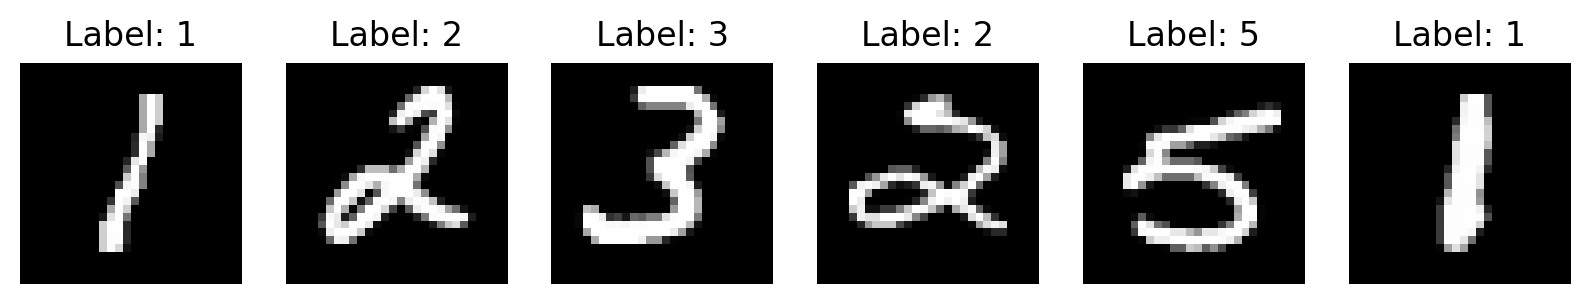

In [ ]:
# Showing the first 6 images from this batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
  axes[i].imshow(images[i].numpy().squeeze(), cmap='Greys_r')
  axes[i].set_title(f'Label: {labels[i].item()}')
  axes[i].axis('off')
plt.show()

## 3. Iteration 1 - Simple MLP (Baseline)


Using the same format and architecture as the BuildNN notebook given to us, we have the following baseline:

- 784 input units (28 x 28 flattened)
- Hidden Layer: 128 units, ReLu
- Hidden Layer: 64 units, ReLu
- Output Later: 10 units

Here we'll be using `nn.Sequential` with `OrderedDict`.

In [ ]:
# Hyperparameters for the network (same as the given BuildNN)
input_size = 784            # Number of input units, must match number of input features
hidden_sizes = [128, 64]    # Number of hidden units
output_size = 10            # Number of output units

# Building the model
model_v1 = nn.Sequential(OrderedDict([
    ('flatten', nn.Flatten()),
    ('fc1', nn.Linear(input_size, hidden_sizes[0])),
    ('relu1', nn.ReLU()),
    ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
    ('relu2', nn.ReLU()),
    ('output', nn.Linear(hidden_sizes[1], output_size)),
]))

model_v1 = model_v1.to(device)
print(model_v1)


Sequential(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
)


### Training Function with Validation

Here we're training more than one model, so we're putting the training loop in a function. The function will do the following:

1. Runs and go through the training data, updating each weights.
2. And after each epoch, it will run and go through the validation set to check the accuracy.
3. Records and keeps track of loss and accuracy for plotting.

In [ ]:
def train_model(model, trainloader, valloader, epochs=10, lr=0.001, verbose=True):

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

  for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    for imgs, lbls in trainloader:
      imgs = imgs.to(device, non_blocking=True)
      lbls = lbls.to(device, non_blocking=True)

      optimizer.zero_grad()
      logits = model(imgs)
      loss = criterion(logits, lbls)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
      for imgs, lbls in valloader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        logits = model(imgs)
        val_loss += criterion(logits, lbls).item()

        preds = logits.argmax(dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100 * correct / total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    if verbose:
      print(f'Epoch {epoch+1:2d}/{epochs} '
            f'train_loss = {avg_train_loss:.4f} '
            f'val_loss = {avg_val_loss:.4f} '
            f'val_acc = {val_acc:.2f}%  ')

  return history


Now training the baseline model. We get the following.

In [ ]:
history_v1 = train_model(model_v1, trainloader, valloader, epochs=10, lr=0.001)

Epoch  1/10 train_loss = 0.5866 val_loss = 0.3479 val_acc = 90.04%  
Epoch  2/10 train_loss = 0.2996 val_loss = 0.3102 val_acc = 90.87%  
Epoch  3/10 train_loss = 0.2434 val_loss = 0.2198 val_acc = 93.49%  
Epoch  4/10 train_loss = 0.1963 val_loss = 0.1891 val_acc = 94.65%  
Epoch  5/10 train_loss = 0.1583 val_loss = 0.1496 val_acc = 95.57%  
Epoch  6/10 train_loss = 0.1378 val_loss = 0.1345 val_acc = 96.12%  
Epoch  7/10 train_loss = 0.1180 val_loss = 0.1244 val_acc = 96.36%  
Epoch  8/10 train_loss = 0.1043 val_loss = 0.1093 val_acc = 96.65%  
Epoch  9/10 train_loss = 0.0895 val_loss = 0.1054 val_acc = 96.77%  
Epoch 10/10 train_loss = 0.0810 val_loss = 0.0994 val_acc = 97.05%  


### Plotting the Training Curves

Here's we're plotting the Train vs. Validation loss, which tells us if we're overfitting. So if the train loss keeps going down but validation loss starts going up, then we're overfitting.

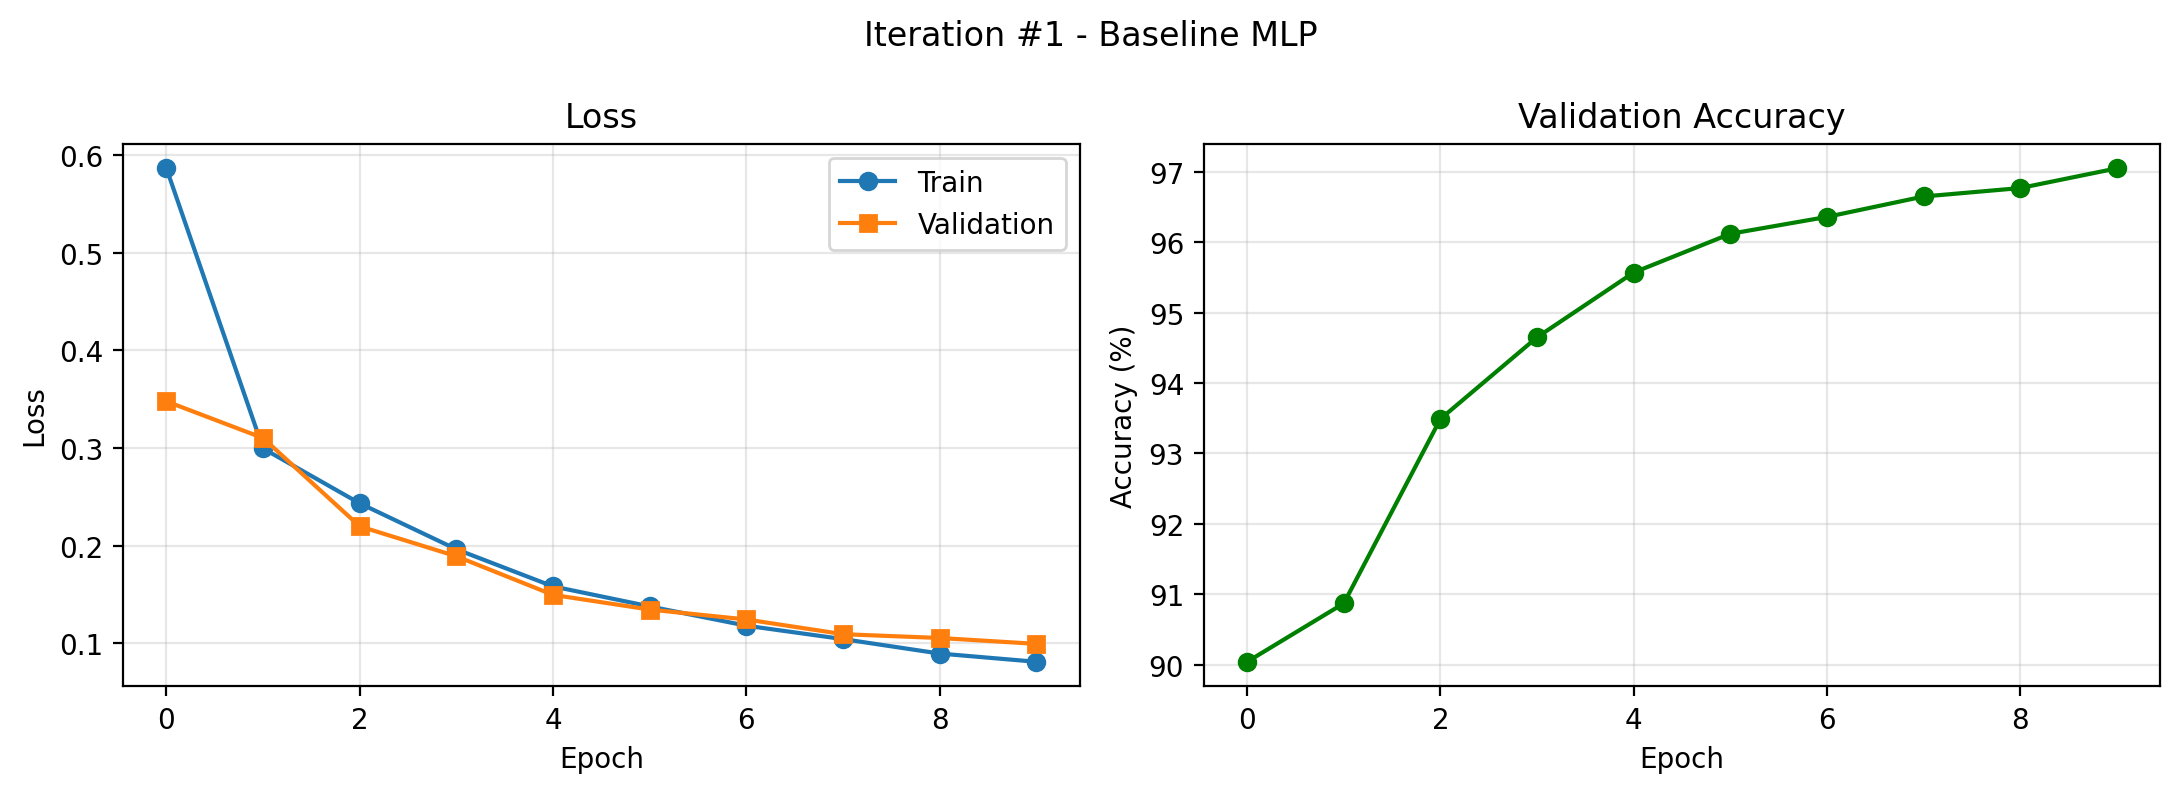

In [ ]:
def plot_history(history, title='Training History'):
  fig, axes = plt.subplots(1, 2, figsize=(11, 4))

  axes[0].plot(history['train_loss'], label='Train', marker='o')
  axes[0].plot(history['val_loss'], label='Validation', marker='s')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].set_title('Loss')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  axes[1].plot(history['val_acc'], color='green', marker='o')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy (%)')
  axes[1].set_title('Validation Accuracy')
  axes[1].grid(True, alpha=0.3)

  fig.suptitle(title)
  plt.tight_layout()
  plt.show()

plot_history(history_v1, 'Iteration #1 - Baseline MLP')

### Evaluating on the MNIST Test Set

Now doing the final test. Here the model has never seen these images before during training.

In [ ]:
def evaluate(model, dataloader):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for imgs, lbls in dataloader:
      imgs = imgs.to(device, non_blocking=True)
      lbls = lbls.to(device, non_blocking=True)
      preds = model(imgs).argmax(dim=1)
      correct += (preds == lbls).sum().item()
      total += lbls.size(0)
  return 100 * correct / total

test_acc_v1 = evaluate(model_v1, testloader)
print(f'Iteration #1 MNIST Test Accuracy: {test_acc_v1:.2f}%')

Iteration #1 MNIST Test Accuracy: 97.09%


## 4. Iteration 2 - Bigger Netword + Dropout

The baseline model gave a good MNIST accuracy. But improving it further we do/implement the following:

1. Bigger Hidden Layers: more space to learn patterns.
2. Droputs: randomly turns off neurons during training which can help prevent overfitting.
3. More Epochs: makes training a bit longer.

Building it as a class we get the following.

In [ ]:
class MLP(nn.Module):

  def __init__(self, hidden_sizes=[512, 256], dropout=0.2):
      super().__init__()

      self.flatten  = nn.Flatten()
      self.fc1      = nn.Linear(784, hidden_sizes[0])
      self.fc2      = nn.Linear(hidden_sizes[0], hidden_sizes[1])
      self.output   = nn.Linear(hidden_sizes[1], 10)
      self.dropout  = nn.Dropout(dropout)

  def forward(self, x):
      x = self.flatten(x)
      x = F.relu(self.fc1(x))
      x = self.dropout(x)
      x = F.relu(self.fc2(x))
      x = self.dropout(x)
      x = self.output(x)
      return x

model_v2 = MLP(hidden_sizes=[512, 256], dropout=0.2).to(device)
print(model_v2)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


Epoch  1/15 train_loss = 0.4702 val_loss = 0.2150 val_acc = 93.85%  
Epoch  2/15 train_loss = 0.2122 val_loss = 0.1730 val_acc = 94.58%  
Epoch  3/15 train_loss = 0.1563 val_loss = 0.1408 val_acc = 95.70%  
Epoch  4/15 train_loss = 0.1260 val_loss = 0.1041 val_acc = 96.79%  
Epoch  5/15 train_loss = 0.1122 val_loss = 0.0976 val_acc = 97.00%  
Epoch  6/15 train_loss = 0.0998 val_loss = 0.0824 val_acc = 97.52%  
Epoch  7/15 train_loss = 0.0865 val_loss = 0.0874 val_acc = 97.25%  
Epoch  8/15 train_loss = 0.0797 val_loss = 0.0771 val_acc = 97.61%  
Epoch  9/15 train_loss = 0.0731 val_loss = 0.0774 val_acc = 97.70%  
Epoch 10/15 train_loss = 0.0682 val_loss = 0.0820 val_acc = 97.61%  
Epoch 11/15 train_loss = 0.0629 val_loss = 0.0734 val_acc = 97.69%  
Epoch 12/15 train_loss = 0.0562 val_loss = 0.0696 val_acc = 97.95%  
Epoch 13/15 train_loss = 0.0583 val_loss = 0.0661 val_acc = 97.83%  
Epoch 14/15 train_loss = 0.0534 val_loss = 0.0717 val_acc = 97.83%  
Epoch 15/15 train_loss = 0.0524 va

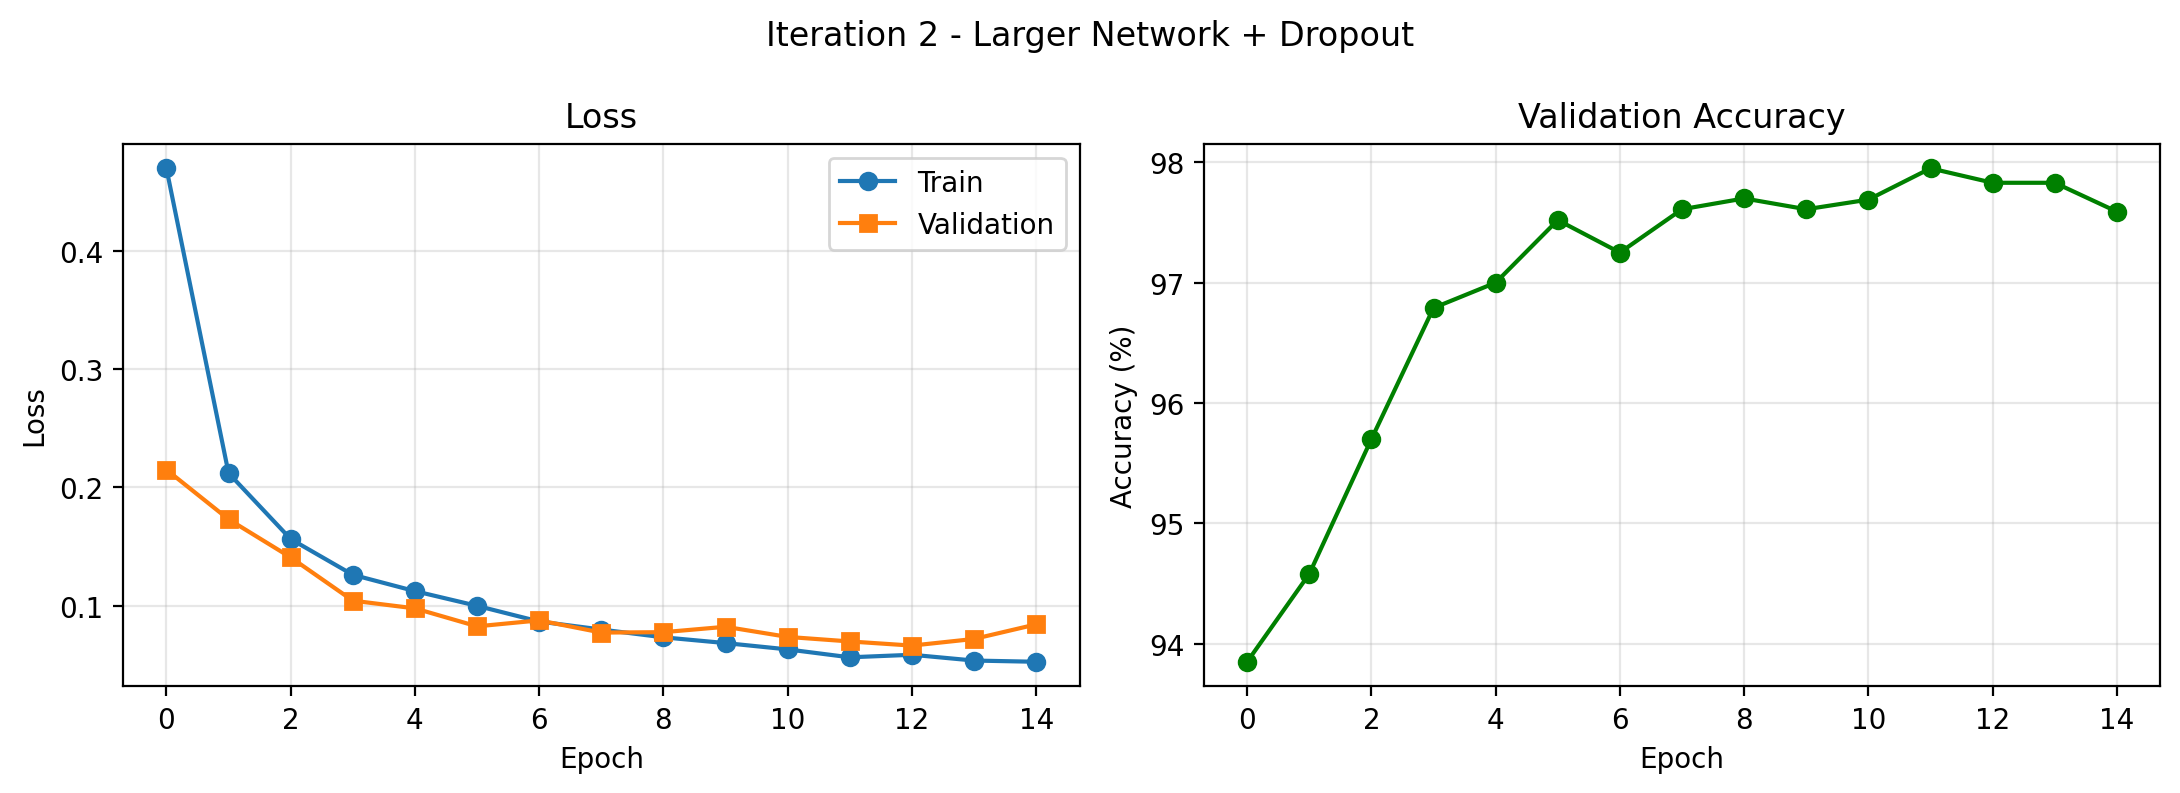


Iteration #2 MNIST Test Accuracy: 97.74%
(Iteration #1 Was: 97.09%)


In [ ]:
history_v2 = train_model(model_v2, trainloader, valloader, epochs=15, lr=0.001)
plot_history(history_v2, 'Iteration 2 - Larger Network + Dropout')

test_acc_v2 = evaluate(model_v2, testloader)
print(f'\nIteration #2 MNIST Test Accuracy: {test_acc_v2:.2f}%')
print(f'(Iteration #1 Was: {test_acc_v1:.2f}%)')


## 4.5. Hyperparameter Sweep

Here we're trying to find the best possible combination of hyper parameters to tune the MLP.

We'll search across different values of hidden layer sizes, dropout rates, and learning rates. And we train each combination for a total of 5 epochs and pick the best resulting validation accuracy.

In [ ]:
# Hyperparameter Sweep that tries different combinations and picks the best one

configs = [
    {'hidden':  [256, 128], 'dropout':  0.0, 'lr':  0.001},
    {'hidden':  [256, 128], 'dropout':  0.2, 'lr':  0.001},
    {'hidden':  [256, 128], 'dropout':  0.5, 'lr':  0.001},
    {'hidden':  [512, 256], 'dropout':  0.0, 'lr':  0.001},
    {'hidden':  [512, 256], 'dropout':  0.2, 'lr':  0.001},
    {'hidden':  [512, 256], 'dropout':  0.5, 'lr':  0.001},
    {'hidden':  [512, 256], 'dropout':  0.2, 'lr':  0.0001},
    {'hidden':  [1024, 512], 'dropout':  0.2, 'lr':  0.001},
]

print(f'Looking {len(configs)} Hyperparameter Combinations...\n')

sweep_results = []
for i, cfg in enumerate(configs):
  print(f"[{i + 1} / {len(configs)}] hidden = {cfg['hidden']}, dropout = {cfg['dropout']}, lr = {cfg['lr']}")
  m = MLP(hidden_sizes=cfg['hidden'], dropout=cfg['dropout']).to(device)
  h = train_model(m, trainloader, valloader, epochs=5, lr=cfg['lr'], verbose=False)
  final_val_acc = h['val_acc'][-1]
  sweep_results.append({**cfg, 'val_acc': final_val_acc})
  print(f'    -> val_acc = {final_val_acc:.2f}%\n')

# Finding the best tuning configuration
best_cfg = max(sweep_results, key=lambda x: x['val_acc'])
print('=' * 45)
print('Hyperparameter Sweep Results:')
print('=' * 45)
for r in sorted(sweep_results, key=lambda x: -x['val_acc']):
    marker = '  <-- BEST CONFIG' if r is best_cfg else ''
    print(f"hidden = {str(r['hidden']):14s} dropout = {r['dropout']:.1f} lr = {r['lr']:.4f} | val_acc = {r['val_acc']:.2f}%{marker}")

# Saving the best hyperparameter config
best_hidden   = best_cfg['hidden']
best_dropout  = best_cfg['dropout']
best_lr       = best_cfg['lr']
print(f"\nBest Hyperparameters Saved: hidden = {best_hidden}, dropout = {best_dropout}, lr = {best_lr}")

Looking 8 Hyperparameter Combinations...

[1 / 8] hidden = [256, 128], dropout = 0.0, lr = 0.001
    -> val_acc = 96.64%

[2 / 8] hidden = [256, 128], dropout = 0.2, lr = 0.001
    -> val_acc = 96.19%

[3 / 8] hidden = [256, 128], dropout = 0.5, lr = 0.001
    -> val_acc = 95.09%

[4 / 8] hidden = [512, 256], dropout = 0.0, lr = 0.001
    -> val_acc = 96.98%

[5 / 8] hidden = [512, 256], dropout = 0.2, lr = 0.001
    -> val_acc = 96.78%

[6 / 8] hidden = [512, 256], dropout = 0.5, lr = 0.001
    -> val_acc = 96.16%

[7 / 8] hidden = [512, 256], dropout = 0.2, lr = 0.0001
    -> val_acc = 93.95%

[8 / 8] hidden = [1024, 512], dropout = 0.2, lr = 0.001
    -> val_acc = 97.55%

Hyperparameter Sweep Results:
hidden = [1024, 512]    dropout = 0.2 lr = 0.0010 | val_acc = 97.55%  <-- BEST CONFIG
hidden = [512, 256]     dropout = 0.0 lr = 0.0010 | val_acc = 96.98%
hidden = [512, 256]     dropout = 0.2 lr = 0.0010 | val_acc = 96.78%
hidden = [256, 128]     dropout = 0.0 lr = 0.0010 | val_acc = 

### Plotting the Sweep Result

Here can visualize the results.

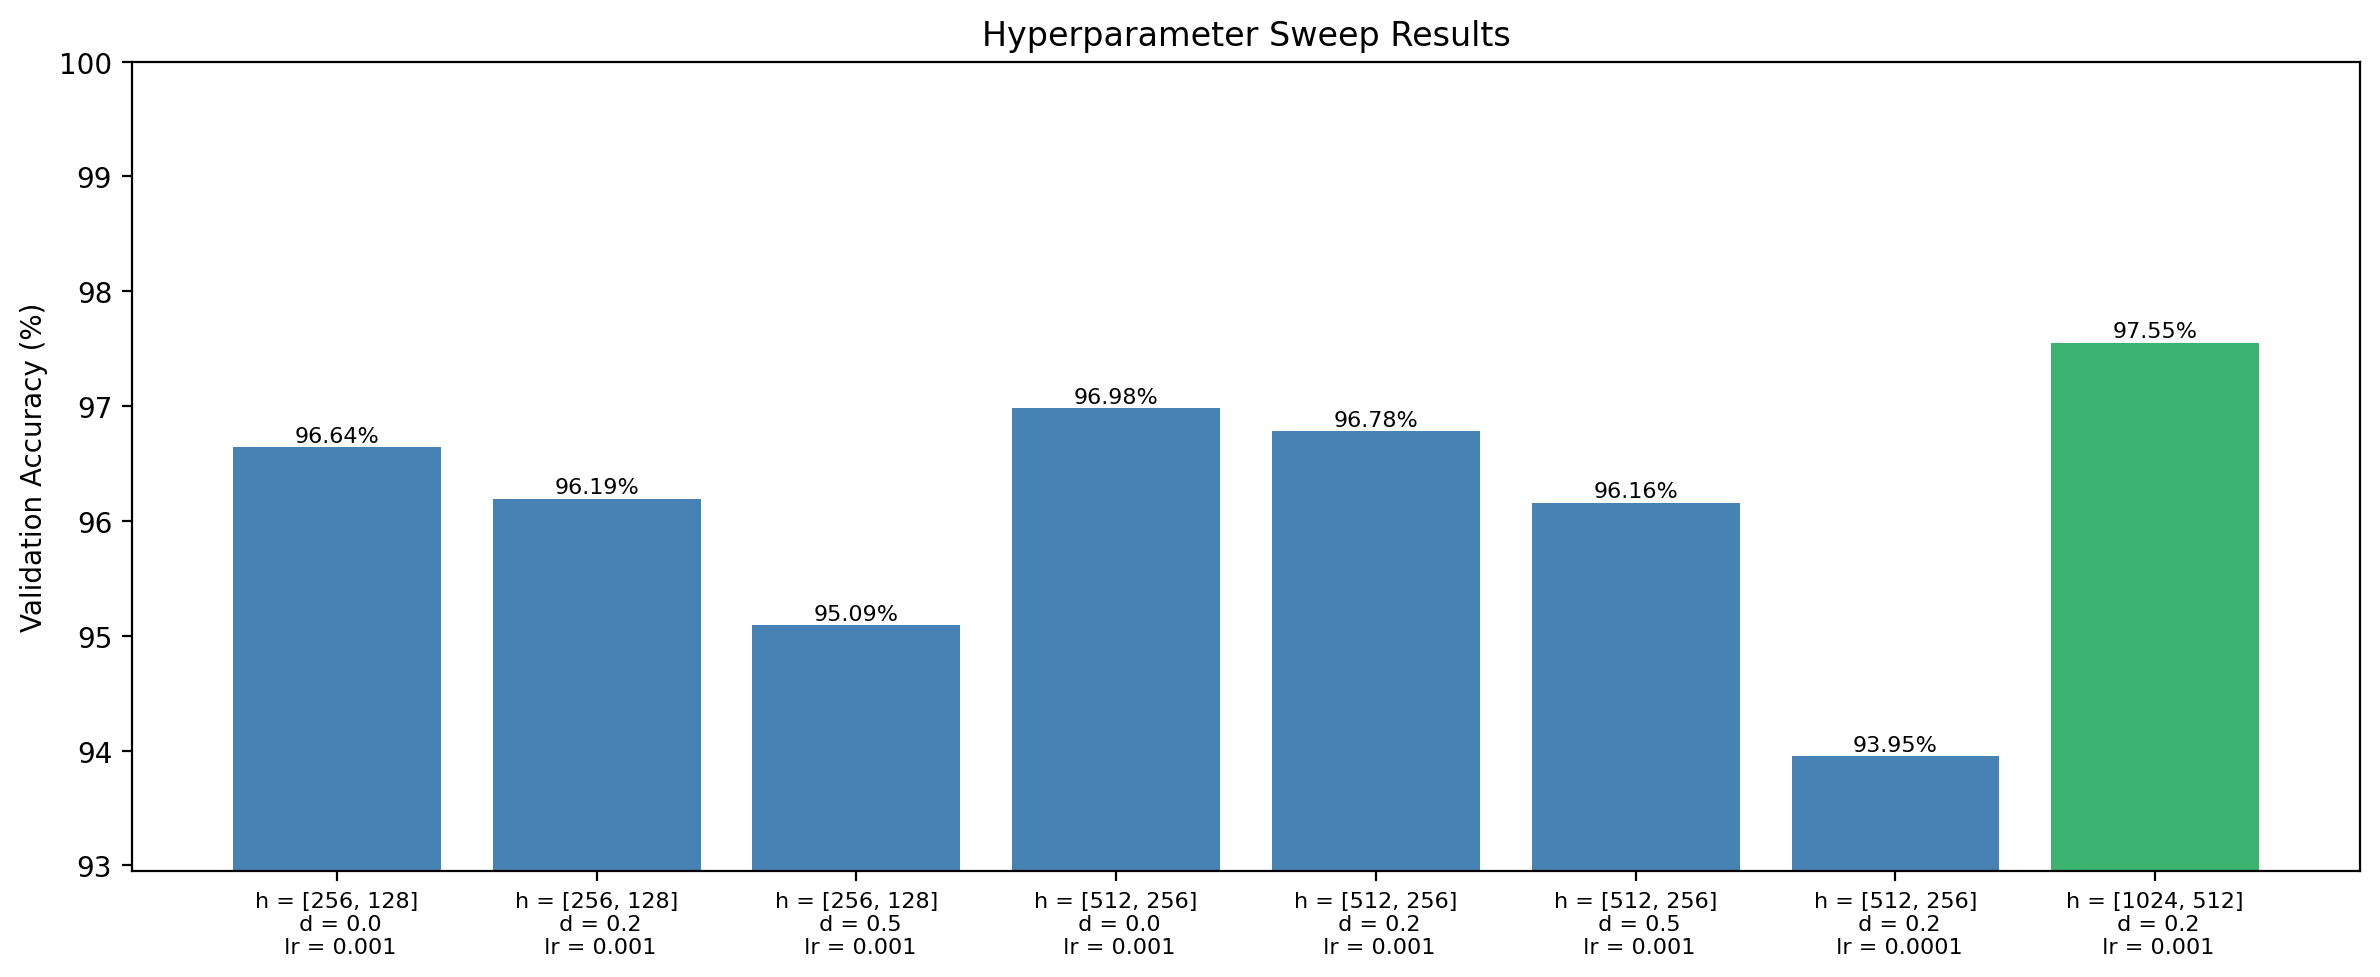

In [ ]:
# Plotting the sweep results
labels = [f"h = {r['hidden']}\n d = {r['dropout']}\n lr = {r['lr']}" for r in sweep_results]
accs = [r['val_acc'] for r in sweep_results]

colors = ['mediumseagreen' if r is best_cfg else 'steelblue' for r in sweep_results]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(sweep_results)), accs, color=colors)
ax.set_xticks(range(len(sweep_results)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Hyperparameter Sweep Results')
ax.set_ylim([min(accs) - 1, 100])
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f'{acc:.2f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## 5. Iteration 3 - Data Augmentation

Since the group's images are gonna vary and be different, we'll be implementing and adding random rotations and small shifts to the training images. We do this so that the model see a variety of slightly different versions of each digit, so it get more stable.

In [ ]:
# Augmented transform: only for the training set
transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Plain transform for validation/testing
transform_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Reloads the training data with the augmentation
trainset_aug_full = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform_aug)
trainset_aug, _   = random_split(trainset_aug_full, [50000, 10000], generator=torch.Generator().manual_seed(7))
trainloader_aug   = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, **loader_kwargs)

print('Augmented Training Set Size:', len(trainset_aug))

Augmented Training Set Size: 50000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Visualizing what the augmented digits look like, we get the following:

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


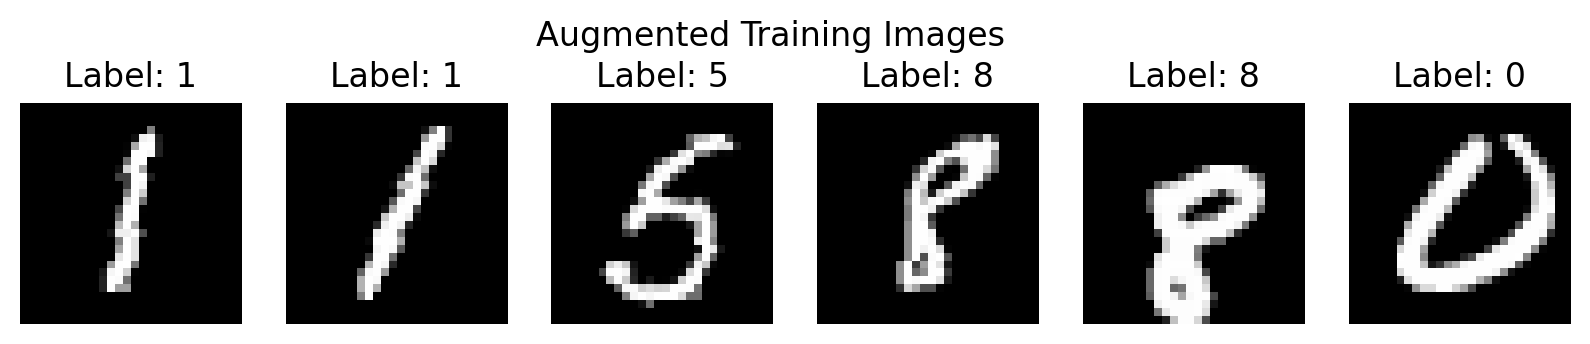

In [ ]:
# Grabs a batch of the augmented images and looks at them
aug_iter = iter(trainloader_aug)
aug_imgs, aug_lbls = aug_iter.__next__()

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(aug_imgs[i].numpy().squeeze(), cmap='Greys_r')
    axes[i].set_title(f'Label: {aug_lbls[i].item()}')
    axes[i].axis('off')
fig.suptitle('Augmented Training Images')
plt.show()

Epoch  1/15 train_loss = 0.8466 val_loss = 0.3067 val_acc = 90.53%  
Epoch  2/15 train_loss = 0.3593 val_loss = 0.1530 val_acc = 95.76%  
Epoch  3/15 train_loss = 0.2818 val_loss = 0.1555 val_acc = 95.81%  
Epoch  4/15 train_loss = 0.2476 val_loss = 0.1426 val_acc = 95.63%  
Epoch  5/15 train_loss = 0.2161 val_loss = 0.0897 val_acc = 97.42%  
Epoch  6/15 train_loss = 0.1981 val_loss = 0.1001 val_acc = 96.72%  
Epoch  7/15 train_loss = 0.1875 val_loss = 0.0893 val_acc = 97.09%  
Epoch  8/15 train_loss = 0.1769 val_loss = 0.0790 val_acc = 97.38%  
Epoch  9/15 train_loss = 0.1681 val_loss = 0.0685 val_acc = 97.96%  
Epoch 10/15 train_loss = 0.1573 val_loss = 0.0724 val_acc = 97.65%  
Epoch 11/15 train_loss = 0.1584 val_loss = 0.0629 val_acc = 98.00%  
Epoch 12/15 train_loss = 0.1491 val_loss = 0.0593 val_acc = 98.30%  
Epoch 13/15 train_loss = 0.1486 val_loss = 0.0721 val_acc = 97.85%  
Epoch 14/15 train_loss = 0.1452 val_loss = 0.0627 val_acc = 98.05%  
Epoch 15/15 train_loss = 0.1429 va

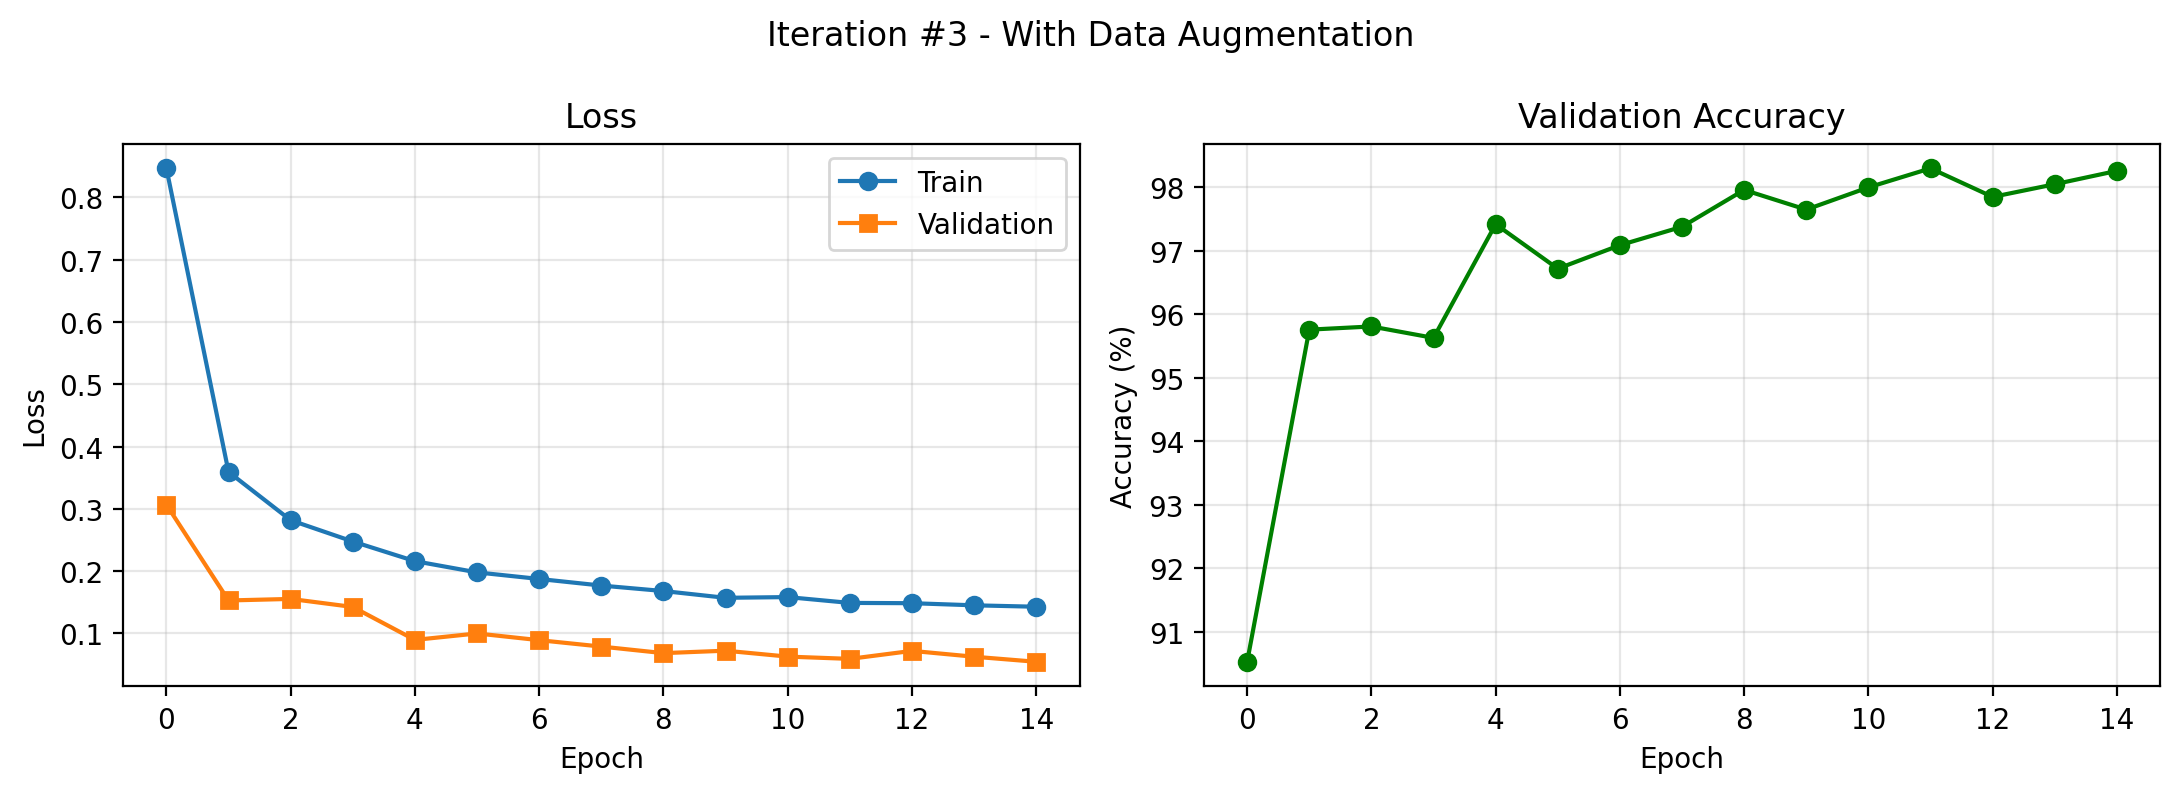


Iteration #3 MNIST Test Accuracy: 98.15%


In [ ]:
# Training another model on the augmented data
model_v3 = MLP(hidden_sizes=best_hidden, dropout=best_dropout).to(device)
history_v3 = train_model(model_v3, trainloader_aug, valloader, epochs=15, lr=best_lr)
plot_history(history_v3, 'Iteration #3 - With Data Augmentation')

test_acc_v3 = evaluate(model_v3, testloader)
print(f'\nIteration #3 MNIST Test Accuracy: {test_acc_v3:.2f}%')

## 6. Comparing All 3 Iterations

Side by side comparison/chart of how each iteration did on the MNIST test dataset.

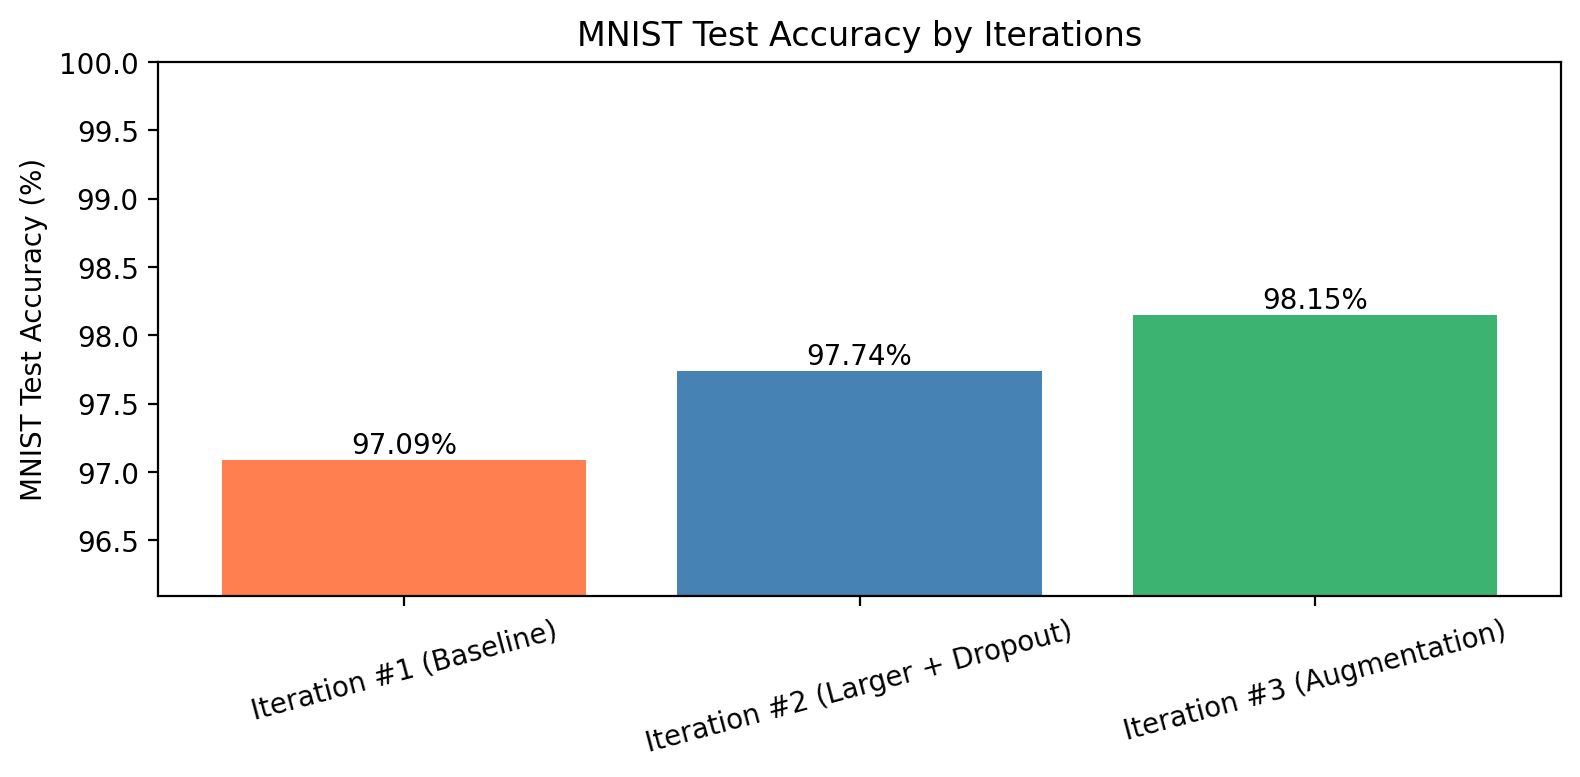

Iteration #1 (Baseline)              97.09%
Iteration #2 (Larger + Dropout)      97.74%
Iteration #3 (Augmentation)          98.15%


In [ ]:
results = {
    'Iteration #1 (Baseline)':          test_acc_v1,
    'Iteration #2 (Larger + Dropout)':  test_acc_v2,
    'Iteration #3 (Augmentation)':      test_acc_v3,
}

fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
accs  = list(results.values())
bars = ax.bar(names, accs, color=['coral', 'steelblue', 'mediumseagreen'])
ax.set_ylabel('MNIST Test Accuracy (%)')
ax.set_ylim([min(accs) - 1, 100])
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, f'{acc:.2f}%', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.title('MNIST Test Accuracy by Iterations')
plt.tight_layout()
plt.show()

for name, acc in results.items():
    print(f'{name:35s}  {acc:.2f}%')

## 7. Saving The Best Model

Here we're saving the best performing model and using it for the other tests.

In [ ]:
all_models = {
    test_acc_v1: model_v1,
    test_acc_v2: model_v2,
    test_acc_v3: model_v3,
}
best_acc = max(all_models.keys())
best_model = all_models[best_acc]

print(f'Best Model MNIST Test Accuracy: {best_acc:.2f}%')
torch.save(best_model.state_dict(), 'best_mlp.pth')
print('Saved to best_mlp.pth')

Best Model MNIST Test Accuracy: 98.15%
Saved to best_mlp.pth


## 8. ProjectDataLoader (Loading the Group's Images)

Now, testing the model on the group's data of handwritten digits. The collected PNG files using the filename format of:

    <label/digit>-<groupID>-<memberID>.png

In [ ]:
import os
import numpy as np
from PIL import Image

def ProjectDataLoader(folder_path="digits_data", invert=True, verbose=True):
    images = []
    labels = []

    # Grabs the sorted list of PNG files
    all_files   = os.listdir(folder_path)
    image_files = sorted(f for f in all_files if f.lower().endswith((".png", ".jpg", ".jpeg")))

    for fname in image_files:
        try:
            label = int(fname[0])
        except ValueError:
            print(f'Skipping {fname}: Could NOT Parse Label From Filename')
            continue

        path = os.path.join(folder_path, fname)
        img = Image.open(path).convert("L")
        img = img.resize((28, 28))
        arr = np.array(img, dtype=np.uint8)

        if invert:
            arr = 255 - arr

        images.append(arr)
        labels.append(label)

    images = np.array(images)
    labels = np.array(labels, dtype=np.int64)

    if verbose:
        print(f"Loaded {len(images)} Images From '{folder_path}'")
        print(f"    images.shape = {images.shape}")
        print(f"    labels.shape = {labels.shape}")

    return images, labels

In [ ]:
# Reading all of the PNG files from the digits folder
images, labels = ProjectDataLoader('/content/drive/MyDrive/digits', invert=False)

Loaded 300 Images From '/content/drive/MyDrive/digits'
    images.shape = (300, 28, 28)
    labels.shape = (300,)


Here is showing a few images of the group's images so we can see that they loaded correctly.

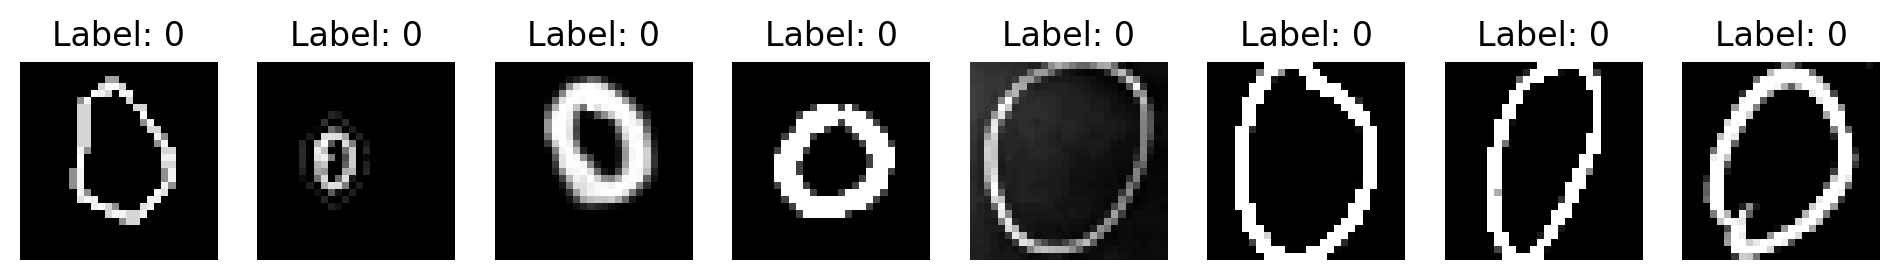

In [ ]:
# Showing the first few images
n_show = min(8, len(images))
fig, axes = plt.subplots(1, n_show, figsize=(12, 2))
if n_show == 1:
  axes = [axes]
for i in range(n_show):
    axes[i].imshow(images[i], cmap='Greys_r')
    axes[i].set_title(f'Label: {labels[i]}')
    axes[i].axis('off')
plt.show()

## 9. Testing the Model on the Group's Images

We convert the NumPy images to PyTorch tensors using the same normalizations that we used for the MNIST training.

In [ ]:
# Converting numpy images to torch tensors and normalizing like MNIST
imgs_tensor = torch.tensor(images, dtype=torch.float32) / 255.0
imgs_tensor = (imgs_tensor - 0.5) / 0.5
imgs_tensor = imgs_tensor.unsqueeze(1)
imgs_tensor = imgs_tensor.to(device)

lbls_tensor = torch.tensor(labels, dtype=torch.long).to(device)

print('imgs_tensor.shape', imgs_tensor.shape)
print('lbls_tensor.shape', lbls_tensor.shape)


imgs_tensor.shape torch.Size([300, 1, 28, 28])
lbls_tensor.shape torch.Size([300])


In [ ]:
# Running the best model on the groups images
best_model.eval()
with torch.no_grad():
    logits = best_model(imgs_tensor)
    preds = logits.argmax(dim=1)

correct = (preds == lbls_tensor).sum().item()
group_acc = 100 * correct / len(labels)

print(f'Group Images Accuracy: {group_acc:.2f}% ({correct} / {len(labels)})')

Group Images Accuracy: 81.67% (245 / 300)


### Accuracy Per Digit

Here the total accuracy is one number and doesn't tell/show us which individual digits the model is bad at. So here, we're breaking down the overall accuracy by which digit the model was looking at.

Per Digit Accuracy On Group Images:
----------------------------------------
  Digit 0:  83.33%    (30 samples)
  Digit 1:  93.33%    (30 samples)
  Digit 2:  80.00%    (30 samples)
  Digit 3:  86.67%    (30 samples)
  Digit 4:  86.67%    (30 samples)
  Digit 5:  80.00%    (30 samples)
  Digit 6:  70.00%    (30 samples)
  Digit 7:  80.00%    (30 samples)
  Digit 8:  73.33%    (30 samples)
  Digit 9:  83.33%    (30 samples)


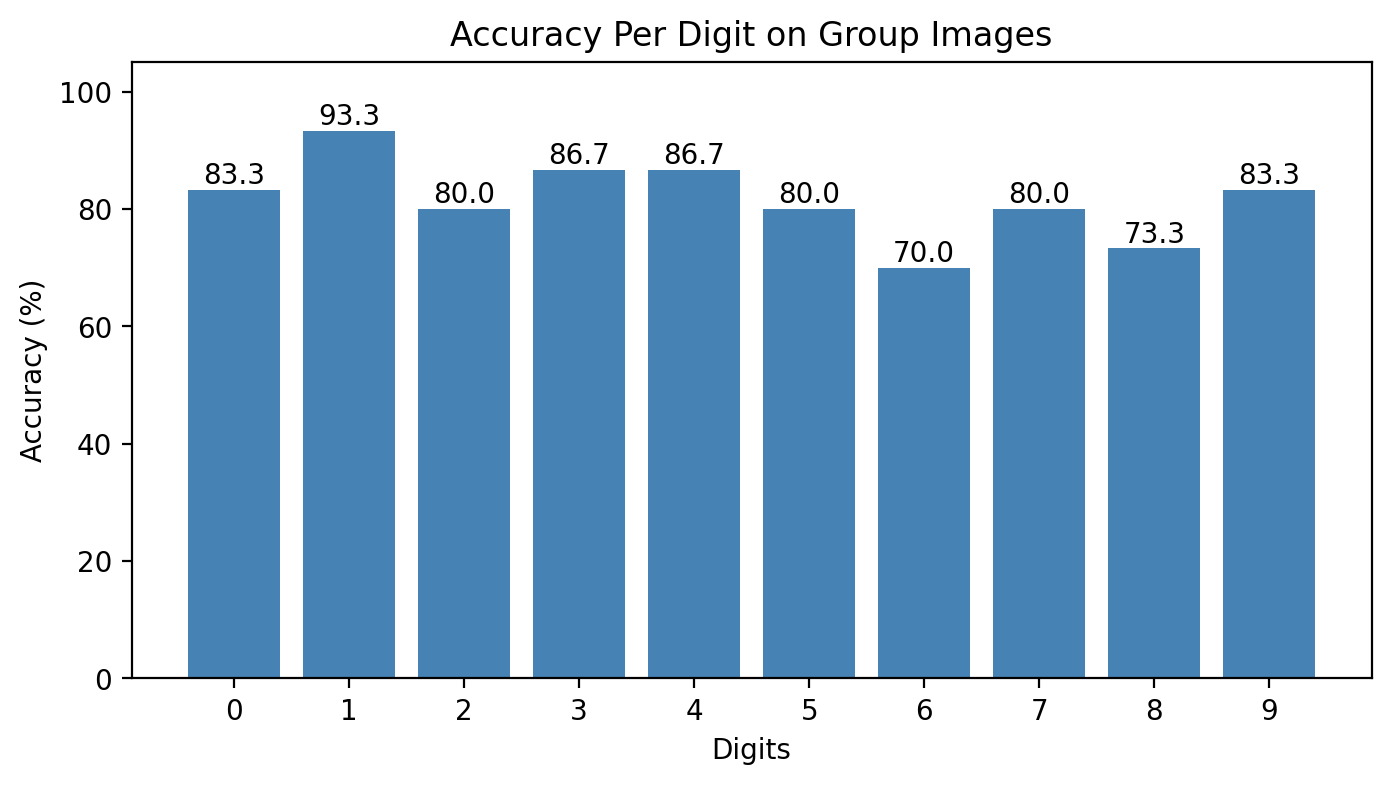

In [ ]:
preds_np = preds.cpu().numpy()
labels_np = lbls_tensor.cpu().numpy()

print('Per Digit Accuracy On Group Images:')
print('-' * 40)
per_digit_acc = []
for d in range(10):
  mask = labels_np == d
  if mask.sum() > 0:
      acc = 100 * (preds_np[mask] == d).mean()
      per_digit_acc.append(acc)
      print(f'  Digit {d}: {acc:6.2f}%    ({mask.sum()} samples)')
  else:
      per_digit_acc.append(0)
      print(f'  Digit {d}: No Samples')

# Plotting
plt.figure(figsize=(8, 4))
plt.bar(range(10), per_digit_acc, color='steelblue')
plt.xticks(range(10))
plt.xlabel('Digits')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Per Digit on Group Images')
plt.ylim([0, 105])
for i, acc in enumerate(per_digit_acc):
    plt.text(i, acc + 1, f'{acc:.1f}', ha='center')
plt.show()

### Looking at the Wrong Ones

Here we're looking at the misclassified images.

Number of Wrong Predictions: 55 out of 300


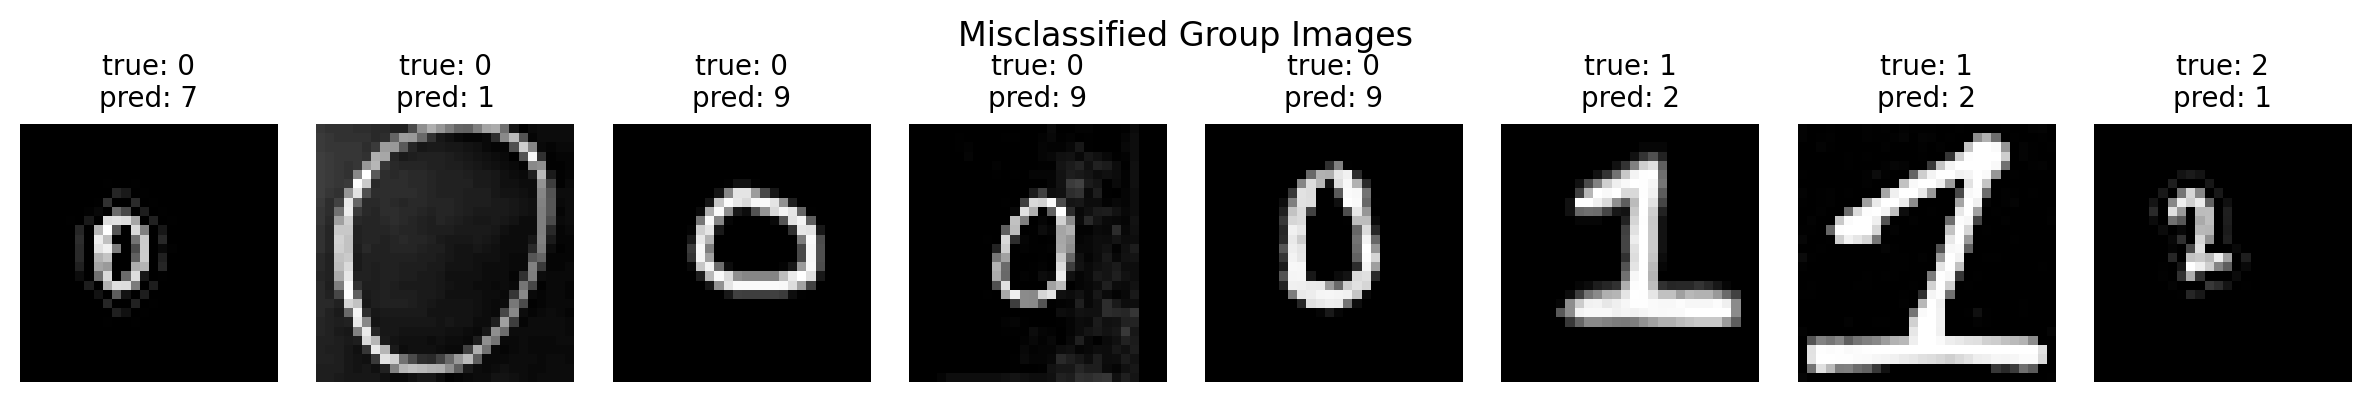

In [ ]:
wrong_mask = preds_np != labels_np
wrong_indices = np.where(wrong_mask)[0]

print(f'Number of Wrong Predictions: {len(wrong_indices)} out of {len(labels)}')

if len(wrong_indices) > 0:
    n_show = min(8, len(wrong_indices))
    fig, axes = plt.subplots(1, n_show, figsize=(12, 2))
    if n_show == 1:
        axes = [axes]
    for i in range(n_show):
        idx = wrong_indices[i]
        axes[i].imshow(images[idx], cmap='Greys_r')
        axes[i].set_title(f'true: {labels_np[idx]}\npred: {preds_np[idx]}', fontsize=10)
        axes[i].axis('off')
    fig.suptitle('Misclassified Group Images')
    plt.tight_layout()
    plt.show()
else:
  print('Nothing Incorrect.')

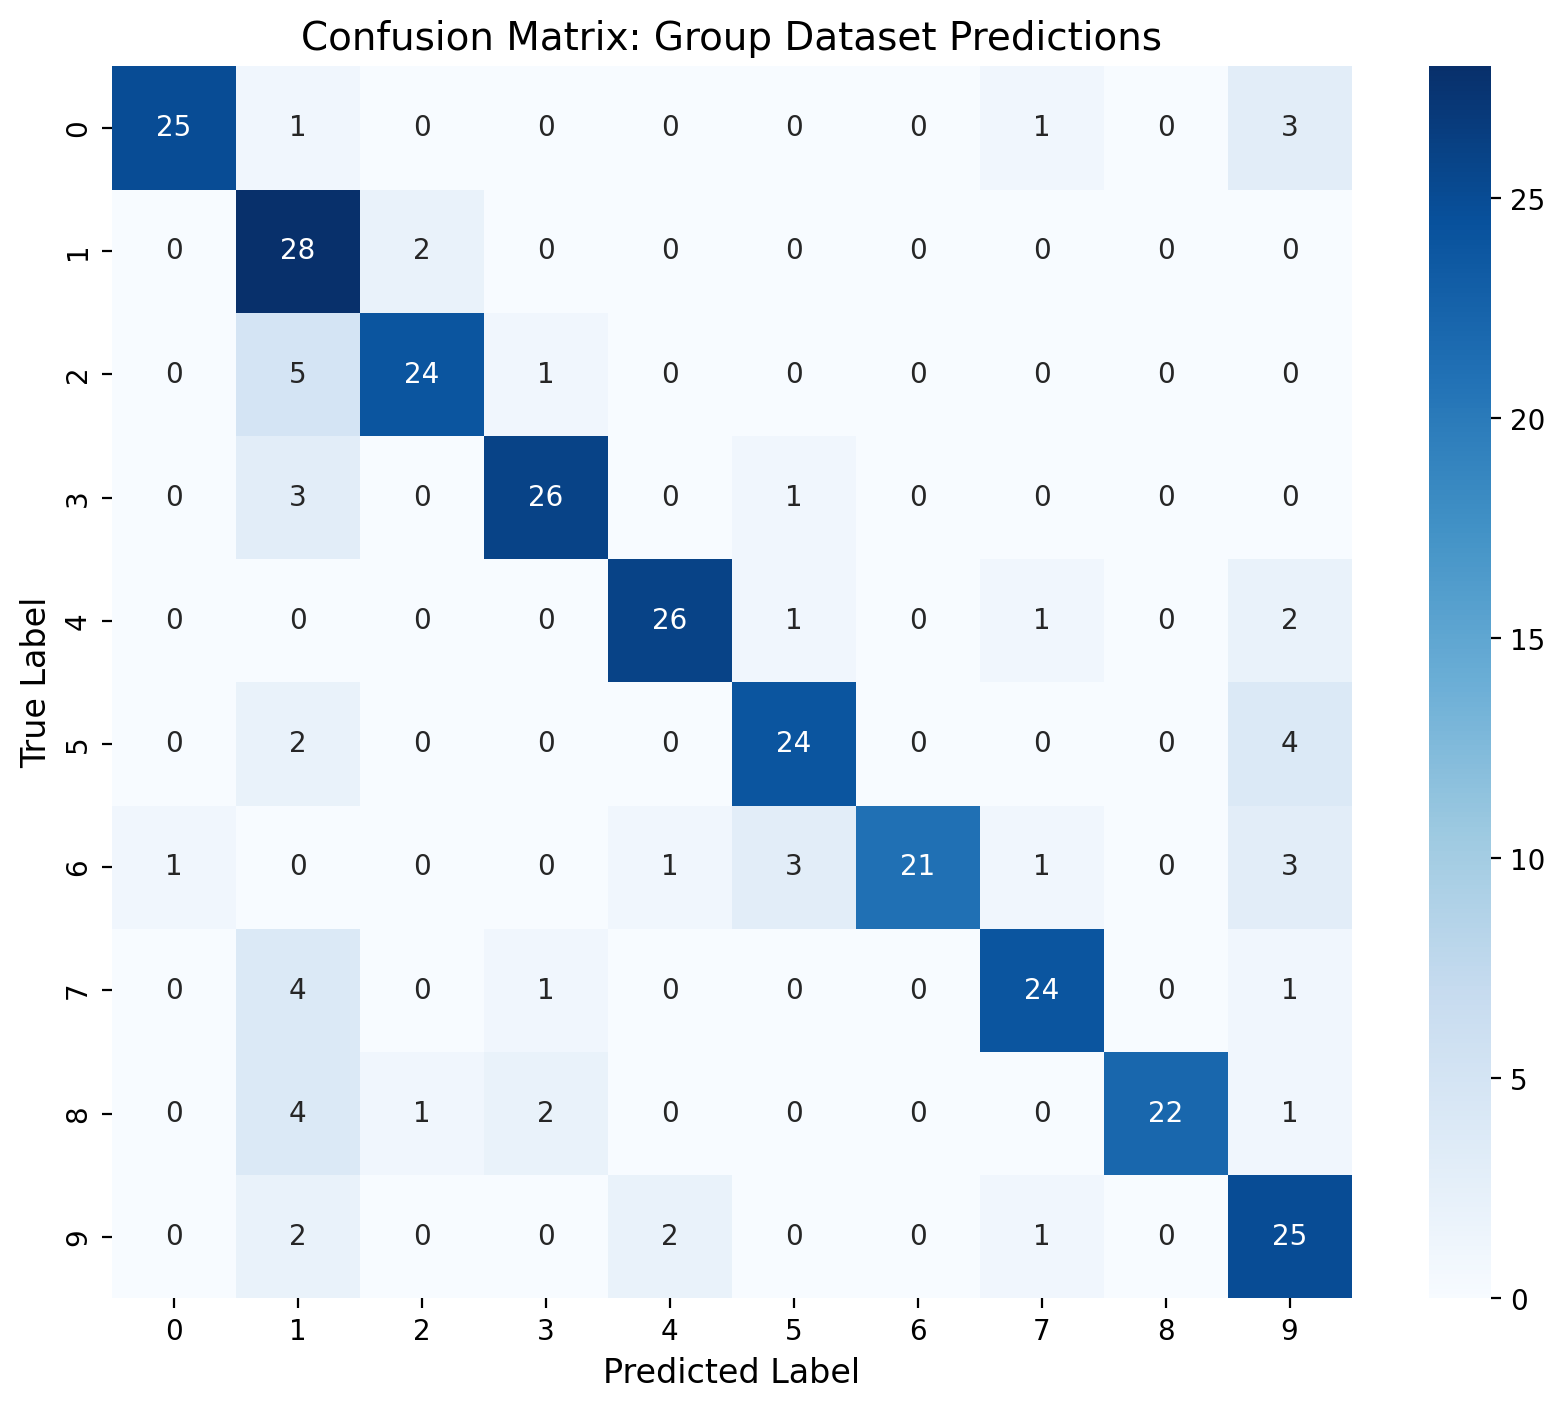

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(labels_np, preds_np)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix: Group Dataset Predictions', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

## 10. Final Results Summary

The outputs of all of the numbers.

In [ ]:
print('=' * 45)
print('FINAL RESULTS')
print('=' * 45)
print(f'MNIST Test Accuracy (Best Model): {best_acc:.2f}%')
print(f'Group Image Accuracy:             {group_acc:.2f}%')
print(f'Difference (MNIST - Group):       {best_acc - group_acc:.2f}%')
print('=' * 45)

FINAL RESULTS
MNIST Test Accuracy (Best Model): 98.15%
Group Image Accuracy:             81.67%
Difference (MNIST - Group):       16.48%


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


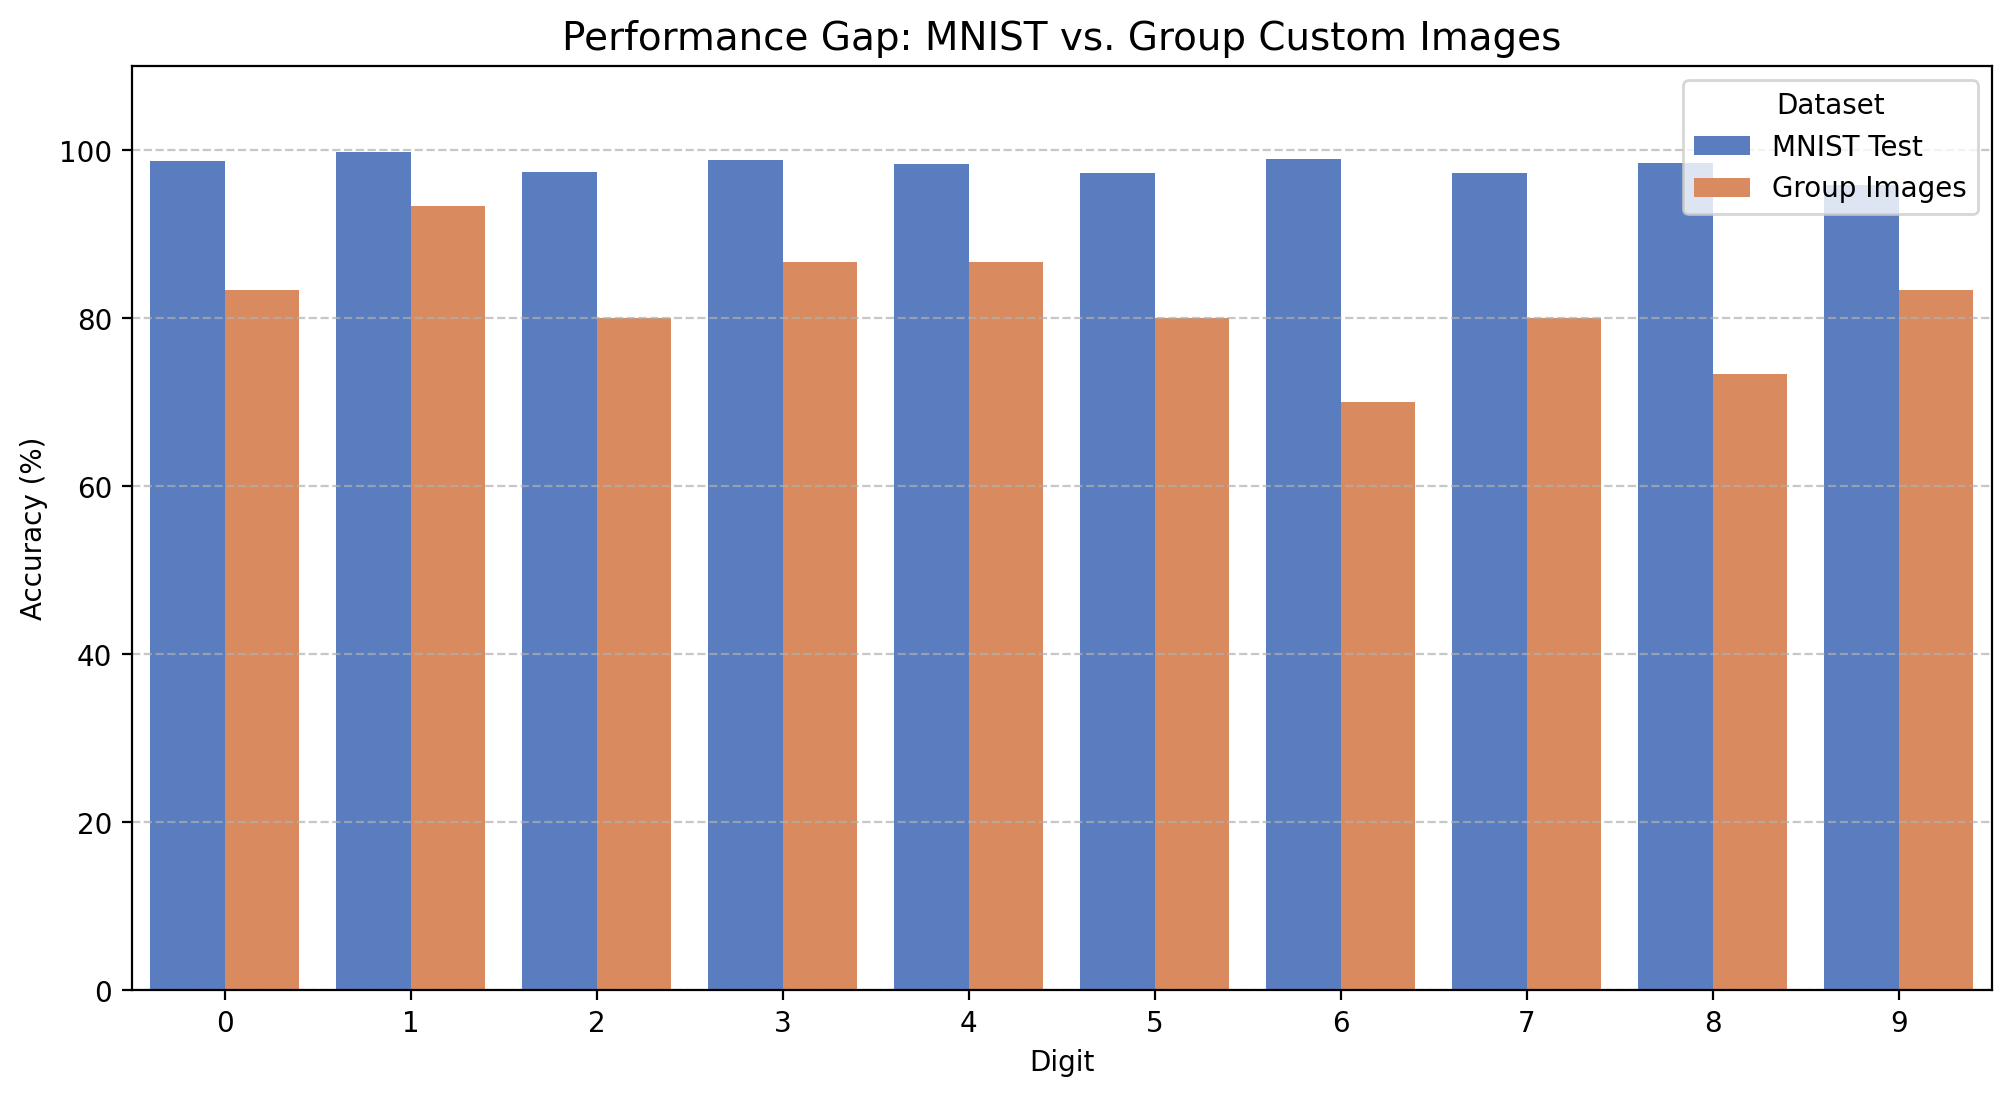

In [ ]:
import pandas as pd
import seaborn as sns

# We'll calculate class-wise accuracy for MNIST test set to compare
model_v3.eval()
mnist_correct = [0]*10
mnist_total = [0]*10
with torch.no_grad():
    for imgs, lbls in testloader:
        imgs = imgs.to(device)
        preds = model_v3(imgs).argmax(dim=1).cpu().numpy()
        lbls = lbls.numpy()
        for p, l in zip(preds, lbls):
            if p == l: mnist_correct[l] += 1
            mnist_total[l] += 1

mnist_class_acc = [100 * c / t for c, t in zip(mnist_correct, mnist_total)]

# Create a comparison dataframe
comparison_data = []
for i in range(10):
    comparison_data.append({'Digit': i, 'Accuracy': mnist_class_acc[i], 'Dataset': 'MNIST Test'})
    comparison_data.append({'Digit': i, 'Accuracy': per_digit_acc[i], 'Dataset': 'Group Images'})

comp_df = pd.DataFrame(comparison_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=comp_df, x='Digit', y='Accuracy', hue='Dataset', palette='muted')
plt.title('Performance Gap: MNIST vs. Group Custom Images', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 11. Checking for Invalid Files

In [ ]:
import os
folder = '/content/drive/MyDrive/digits'
all_files = os.listdir(folder)

print(f"Total Entries In Folder: {len(all_files)}\n")

expected_pattern = []
wrong_extension = []
no_digit_prefix = []
not_a_file = []

for f in sorted(all_files):
    full_path = os.path.join(folder, f)
    if not os.path.isfile(full_path):
        not_a_file.append(f)
    elif not f.lower().endswith('.png'):
        wrong_extension.append(f)
    elif not f[0].isdigit():
        no_digit_prefix.append(f)
    else:
        expected_pattern.append(f)

print(f"Files Match Expected Pattern: {len(expected_pattern)}")

print(f"\nWrong Extention (not .png): {len(wrong_extension)}")
for f in wrong_extension[:20]:
    print(f"    {f}")

print(f"\nNo Digit Prefix: {len(no_digit_prefix)}")
for f in no_digit_prefix[:20]:
    print(f"    {f}")

print(f"\nNot a File: {len(not_a_file)}")
for f in not_a_file[:20]:
    print(f"    {f}")

Total Entries In Folder: 301

Files Match Expected Pattern: 290

Wrong Extention (not .png): 11
    0-6-4.jpg
    1-6-4.jpg
    2-6-4.jpg
    3-6-4.jpg
    4-6-4.jpg
    5-6-4.jpg
    6-6-4.jpg
    7-6-4.jpg
    8-6-4.jpg
    9-6-4.jpg
    notes.txt

No Digit Prefix: 0

Not a File: 0
